# DAY-3 DATA ANAYLSIS


In [1]:
import pandas as pd
import random
import matplotlib.pyplot as plt

In [2]:
names = [
    "Ali","Sara","Ahmed","Fatima","Usman","Ayesha",
    "Hamza","Noor","Bilal","Zainab","Hassan","Hira",
    "Danish","Iqra","Omar","Maham","Talha","Anum",
    "Saad","Maryam","Asad","Komal","Noman","Eman",
    "Farhan","Laiba","Shayan","Amna","Raza","Sana"
]

courses = [
    "AI",
    "Data Science",
    "Software Engineering",
    "Cyber Security"
]

genders = [
    "Male",
    "Female"
]

students = []

for name in names:
    students.append({
        "Student Name": name,
        "Age": random.randint(18, 23),
        "Gender": random.choice(genders),
        "Course": random.choice(courses),
        "Attendance": random.randint(60, 100),
        "Assignment Score": random.randint(50, 100),
        "Midterm Score": random.randint(50, 100),
        "Final Score": random.randint(50, 100)
    })


In [3]:
df = pd.DataFrame(students)

In [4]:
print(df)

   Student Name  Age  Gender                Course  Attendance  \
0           Ali   22    Male        Cyber Security          63   
1          Sara   18  Female          Data Science          99   
2         Ahmed   23  Female                    AI          75   
3        Fatima   23  Female          Data Science          94   
4         Usman   22    Male        Cyber Security          62   
5        Ayesha   18  Female        Cyber Security          69   
6         Hamza   19  Female          Data Science          77   
7          Noor   19  Female  Software Engineering          88   
8         Bilal   21  Female  Software Engineering          62   
9        Zainab   21  Female        Cyber Security          67   
10       Hassan   23  Female                    AI          82   
11         Hira   20  Female        Cyber Security          68   
12       Danish   23  Female  Software Engineering          78   
13         Iqra   22    Male  Software Engineering          91   
14        

In [5]:
df.to_csv("student_performance.csv", index=False)

In [6]:
df = pd.read_csv("student_performance.csv")

print(df.head())

  Student Name  Age  Gender          Course  Attendance  Assignment Score  \
0          Ali   22    Male  Cyber Security          63                75   
1         Sara   18  Female    Data Science          99                83   
2        Ahmed   23  Female              AI          75                61   
3       Fatima   23  Female    Data Science          94                79   
4        Usman   22    Male  Cyber Security          62                50   

   Midterm Score  Final Score  
0             81           60  
1             86           59  
2             56           94  
3             73           86  
4             75           85  


In [7]:
print(df.info())

print()

print(df.describe())

print()

print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Student Name      30 non-null     object
 1   Age               30 non-null     int64 
 2   Gender            30 non-null     object
 3   Course            30 non-null     object
 4   Attendance        30 non-null     int64 
 5   Assignment Score  30 non-null     int64 
 6   Midterm Score     30 non-null     int64 
 7   Final Score       30 non-null     int64 
dtypes: int64(5), object(3)
memory usage: 2.0+ KB
None

             Age  Attendance  Assignment Score  Midterm Score  Final Score
count  30.000000   30.000000         30.000000      30.000000    30.000000
mean   20.800000   79.700000         75.866667      74.366667    73.700000
std     1.769473   11.867516         14.984436      14.353861    13.744341
min    18.000000   62.000000         50.000000      50.000000    50.000000
25%    

In [8]:
print(df.isnull().sum())

Student Name        0
Age                 0
Gender              0
Course              0
Attendance          0
Assignment Score    0
Midterm Score       0
Final Score         0
dtype: int64


In [9]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df["Attendance"] = df["Attendance"].clip(0,100)

In [12]:
print("Average Assignment Score:", df["Assignment Score"].mean())

print("Average Midterm Score:", df["Midterm Score"].mean())

print("Average Final Score:", df["Final Score"].mean())

Average Assignment Score: 75.86666666666666
Average Midterm Score: 74.36666666666666
Average Final Score: 73.7


In [13]:
highest = df.loc[df["Final Score"].idxmax()]
print(highest)

Student Name                       Bilal
Age                                   21
Gender                            Female
Course              Software Engineering
Attendance                            62
Assignment Score                      83
Midterm Score                         77
Final Score                           98
Name: 8, dtype: object


In [14]:
lowest = df.loc[df["Final Score"].idxmin()]
print(lowest)

Student Name                Saad
Age                           21
Gender                      Male
Course              Data Science
Attendance                    85
Assignment Score             100
Midterm Score                 64
Final Score                   50
Name: 18, dtype: object


In [15]:
low_attendance = df[df["Attendance"] < 75]

print(low_attendance)

   Student Name  Age  Gender                Course  Attendance  \
0           Ali   22    Male        Cyber Security          63   
4         Usman   22    Male        Cyber Security          62   
5        Ayesha   18  Female        Cyber Security          69   
8         Bilal   21  Female  Software Engineering          62   
9        Zainab   21  Female        Cyber Security          67   
11         Hira   20  Female        Cyber Security          68   
14         Omar   23  Female        Cyber Security          74   
20         Asad   23    Male          Data Science          65   
25        Laiba   18    Male          Data Science          70   
27         Amna   20    Male          Data Science          62   

    Assignment Score  Midterm Score  Final Score  
0                 75             81           60  
4                 50             75           85  
5                 83             69           52  
8                 83             77           98  
9                 

In [16]:
at_risk = df[
    (df["Final Score"] < 50) |
    (df["Attendance"] < 75)
]

print(at_risk)

   Student Name  Age  Gender                Course  Attendance  \
0           Ali   22    Male        Cyber Security          63   
4         Usman   22    Male        Cyber Security          62   
5        Ayesha   18  Female        Cyber Security          69   
8         Bilal   21  Female  Software Engineering          62   
9        Zainab   21  Female        Cyber Security          67   
11         Hira   20  Female        Cyber Security          68   
14         Omar   23  Female        Cyber Security          74   
20         Asad   23    Male          Data Science          65   
25        Laiba   18    Male          Data Science          70   
27         Amna   20    Male          Data Science          62   

    Assignment Score  Midterm Score  Final Score  
0                 75             81           60  
4                 50             75           85  
5                 83             69           52  
8                 83             77           98  
9                 

In [17]:
course_average = df.groupby("Course")["Final Score"].mean()

print(course_average)

Course
AI                      83.200000
Cyber Security          64.888889
Data Science            74.888889
Software Engineering    76.714286
Name: Final Score, dtype: float64


In [18]:
correlation = df["Attendance"].corr(df["Final Score"])

print("Correlation:", correlation)

Correlation: -0.11430747902633227


In [19]:
import os

os.makedirs("charts", exist_ok=True)

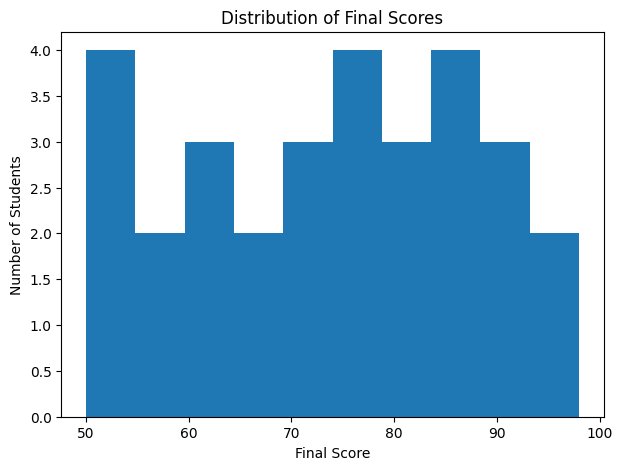

In [20]:
plt.figure(figsize=(7,5))

plt.hist(df["Final Score"], bins=10)

plt.title("Distribution of Final Scores")

plt.xlabel("Final Score")

plt.ylabel("Number of Students")

plt.savefig("charts/score_distribution.png")

plt.show()

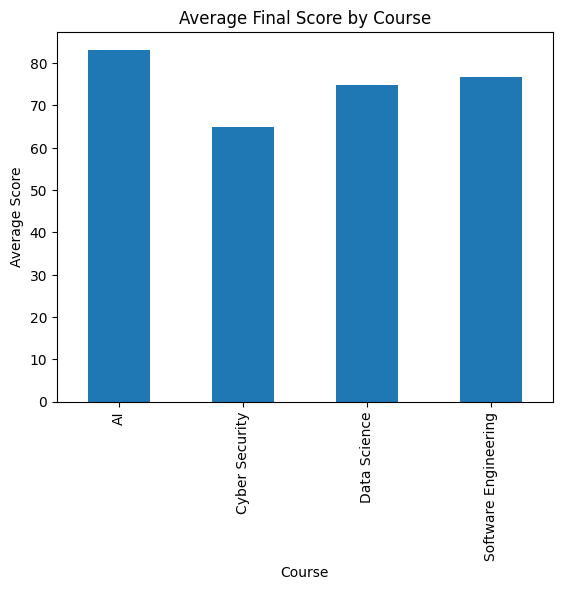

In [21]:
course_average.plot(kind="bar")

plt.title("Average Final Score by Course")

plt.xlabel("Course")

plt.ylabel("Average Score")

plt.savefig("charts/average_score_by_course.png")

plt.show()

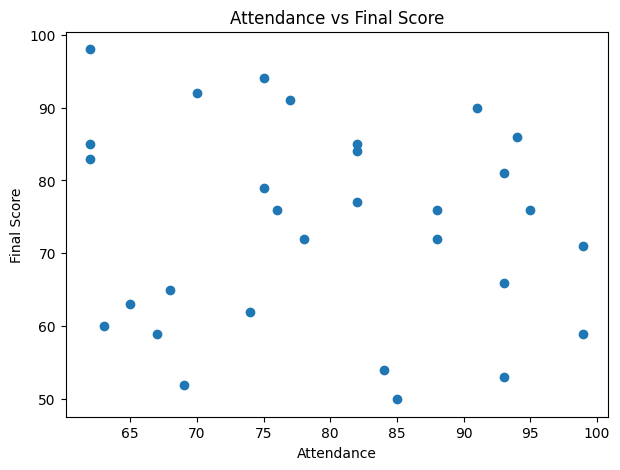

In [22]:
plt.figure(figsize=(7,5))

plt.scatter(df["Attendance"], df["Final Score"])

plt.title("Attendance vs Final Score")

plt.xlabel("Attendance")

plt.ylabel("Final Score")

plt.savefig("charts/attendance_vs_final_score.png")

plt.show()

In [23]:
from google.colab import files
files.download("student_performance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Day4_DATA_ANALYSIS**

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.impute import SimpleImputer

In [25]:
df = pd.read_csv("student_performance.csv")

df.head()

,Student Name,Age,Gender,Course,Attendance,Assignment Score,Midterm Score,Final Score
0,Ali,22,Male,Cyber Security,63,75,81,60
1,Sara,18,Female,Data Science,99,83,86,59
2,Ahmed,23,Female,AI,75,61,56,94
3,Fatima,23,Female,Data Science,94,79,73,86
4,Usman,22,Male,Cyber Security,62,50,75,85


In [26]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Student Name      30 non-null     object
 1   Age               30 non-null     int64 
 2   Gender            30 non-null     object
 3   Course            30 non-null     object
 4   Attendance        30 non-null     int64 
 5   Assignment Score  30 non-null     int64 
 6   Midterm Score     30 non-null     int64 
 7   Final Score       30 non-null     int64 
dtypes: int64(5), object(3)
memory usage: 2.0+ KB
None
             Age  Attendance  Assignment Score  Midterm Score  Final Score
count  30.000000   30.000000         30.000000      30.000000    30.000000
mean   20.800000   79.700000         75.866667      74.366667    73.700000
std     1.769473   11.867516         14.984436      14.353861    13.744341
min    18.000000   62.000000         50.000000      50.000000    50.000000
25%    2

In [27]:
imputer = SimpleImputer(strategy="mean")

numerical_columns = [
    "Attendance",
    "Assignment Score",
    "Midterm Score",
    "Final Score"
]

df[numerical_columns] = imputer.fit_transform(df[numerical_columns])

In [28]:
df["Attendance"] = df["Attendance"].clip(0,100)

In [29]:
df["Pass"] = (df["Final Score"] >= 75).astype(int)

In [30]:
df[["Final Score","Pass"]].head()

,Final Score,Pass
0,60.0,0
1,59.0,0
2,94.0,1
3,86.0,1
4,85.0,1


In [31]:
X = df[
    [
        "Attendance",
        "Assignment Score",
        "Midterm Score",
        "Final Score"
    ]
]

y = df["Pass"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [34]:
y_pred = model.predict(X_test)

print(y_pred)

[1 1 0 1 1 0]


In [35]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8333333333333334


In [36]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2 1]
 [0 3]]


In [37]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.75      1.00      0.86         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6



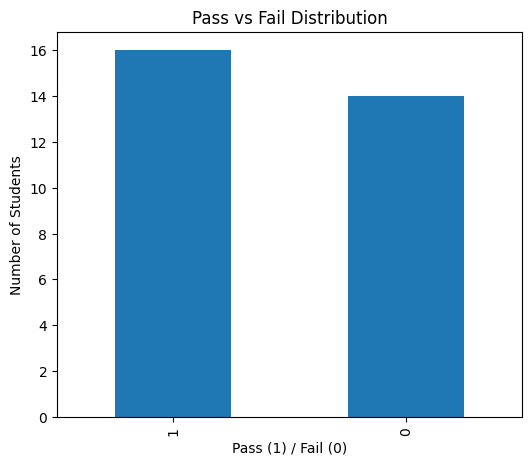

In [38]:
plt.figure(figsize=(6,5))

df["Pass"].value_counts().plot(kind="bar")

plt.title("Pass vs Fail Distribution")

plt.xlabel("Pass (1) / Fail (0)")

plt.ylabel("Number of Students")

plt.savefig("charts/pass_fail_distribution.png")

plt.show()

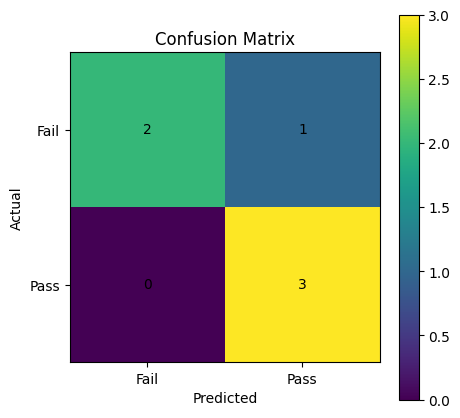

In [39]:
plt.figure(figsize=(5,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks([0,1],["Fail","Pass"])

plt.yticks([0,1],["Fail","Pass"])

for i in range(2):
    for j in range(2):
        plt.text(j,i,str(cm[i,j]),
                 ha="center",
                 va="center")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("charts/confusion_matrix.png")

plt.show()